# Supplier Risk & Performance Scoring

A sector-independent (non-defense) supply chain analytics project. This notebook walks through the full v2 pipeline built in `src/`:

1. A synthetic, intentionally messy supplier dataset (generated with Faker for a Turkish SME/large-industry context), including real Turkish business-rule fields (VKN tax ID, KOSGEB-aligned company size)
2. A profile-driven, source-agnostic cleaning engine (`src/cleaning/`) — new ERP source = new YAML profile, not new code
3. **Two independent risk axes**, deliberately not blended into one number:
   - `risk_score` — operational/performance risk (delivery, price volatility, concentration, quality)
   - `financial_risk_score` — financial/solvency risk (overdue debt, leverage, payment defaults), conceptually inspired by a Findeks Ticari Risk Raporu
4. Concentration risk via the **Herfindahl-Hirschman Index (HHI)**, both portfolio-wide and per-sector
5. Turkish practitioner-grounded due-diligence red flags (export documentation, upfront-payment demands, site visits), and a **CBAM/CSRD compliance exposure flag** for a dated, real 2026 EU regulation
6. Visual exploration of all of the above, and a sensitivity check on the scoring weights
7. **AHP (Analytic Hierarchy Process)**-derived weights — a rigorous, consistency-checked cross-check of the asserted default weights
8. **Risk trend over time** — the same suppliers re-scored across four quarters, with automatic detection of period-to-period risk migrations

The scored output (`reports/supplier_risk_scores.csv`) is what feeds the Power BI dashboard.

In [1]:
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")  # lets us import the scoring functions, not just the CSV outputs

sns.set_theme(style="whitegrid")
RISK_COLORS = {"Low": "#2ca02c", "Medium": "#ff9800", "High": "#d62728"}
RISK_ORDER = ["Low", "Medium", "High"]
pd.set_option("display.max_columns", None)

## 1. The raw data problem

Real supplier exports are rarely clean. To make that concrete (and to have something genuine to clean), `src/generate_suppliers.py` builds a synthetic dataset with the same problems a real Excel export from multiple ERP systems tends to have: mixed date formats, mixed decimal separators, inconsistent category labels, missing cells, and casing noise.

In [2]:
raw_df = pd.read_csv("../data/raw/suppliers_raw.csv", encoding="utf-8-sig")
print(f"{len(raw_df)} suppliers, {raw_df.shape[1]} columns")
raw_df.head()

85 suppliers, 30 columns


,supplier_id,company_name,sector,city,company_size,founded_year,employee_count,vkn,supplier_annual_revenue_tl,annual_purchase_volume_tl,total_orders_last_year,late_orders_last_year,price_q1,price_q2,price_q3,price_q4,units_shipped_last_year,units_returned_last_year,contract_start_date,last_audit_date,payment_terms_days,iso_certified,overdue_debt_ratio,debt_to_revenue_ratio,payment_default_last_3y,has_export_documentation,requires_full_upfront_payment,site_visit_verified,exports_to_eu,has_emissions_reporting_capability
0,SUP079,Şafak Nakliyat Tic.,Lojistik,İstanbul,Küçük,1994.0,11.0,5899642355,42368015.62,9499698.40,51,14.0,"137,47","135,27",149.82,151.83,6386,764.0,05-05-18,NaN,45.0,No,"0,11","0,71",hayır,Evet,NaN,NaN,Hayır,Hayır
1,SUP001,KORUTÜRK ASLAN İPLIK SAN. TIC. LTD. ŞTI.,Tekstil,Trabzon,orta,2009.0,157.0,4794026545,"225.584.135,67","5.492.821,36",134,38.0,"322,41",313.40,"317,95",281.45,46048,6596.0,02.08.2018,29/09/2024,45.0,1,0.05,0.41,hayır,evet,No,0,EVET,EVET
2,SUP069,Şama Yıldırım Gıda San. Tic. Ltd. Şti.,Gıda ve İçecek,Manisa,ORTA,2001.0,217.0,8434540195,315353859.35,NaN,53,8.0,857.98,878.56,844.22,"817,45",90698,3841.0,07/07/2020,29-10-24,45.0,No,NaN,"0,88",hayır,true,0,1,0,No
3,SUP023,Karadeniz Demir Çelik Tic.,Metal ve Çelik,VAN,Small,2000.0,40.0,8701436349,"81.804.912,11",8579252.98,21,8.0,105.75,"101,81","97,31",100.70,8488,872.0,28.05.2024,16/01/2026,NaN,Hayır,"0,18",0.70,No,Yes,No,false,HAYIR,Yes
4,SUP013,ÇORLU İNŞAAT MALZEMELERI SAN. TIC. LTD. ŞTI.,İnşaat Malzemeleri,Şanlıurfa,ORTA,1981.0,147.0,1733754337,936892914.12,122774942.18,119,18.0,253.32,"249,48","230,80",253.41,108235,7620.0,2022-06-02,28-11-24,30.0,No,0.05,"0,26",Hayır,evet,0,Hayır,Hayır,hayır


In [3]:
print("Raw 'company_size' labels actually found in the data (should be one value, not four):")
print(sorted(raw_df["company_size"].dropna().unique()))
print()

print("Raw 'contract_start_date' values (sample) — four different date formats mixed together:")
print(raw_df["contract_start_date"].dropna().sample(6, random_state=1).tolist())
print()

print("Raw 'price_q1' values (sample) — Turkish comma-decimal and plain dot-decimal mixed:")
print(raw_df["price_q1"].dropna().sample(6, random_state=2).tolist())
print()

print("Missing values per column:")
print(raw_df.isna().sum())

Raw 'company_size' labels actually found in the data (should be one value, not four):
['BÜYÜK', 'Büyük', 'KÜÇÜK', 'Küçük', 'Medium', 'Micro', 'Mikro', 'MİKRO', 'ORTA', 'Orta', 'Small', 'büyük', 'küçük', 'mikro', 'orta']

Raw 'contract_start_date' values (sample) — four different date formats mixed together:
['2024-07-01', '09/11/2020', '25-09-24', '29-06-17', '04/03/2018', '12-01-18']

Raw 'price_q1' values (sample) — Turkish comma-decimal and plain dot-decimal mixed:
['56,22', '93,90', '182.99', '119.37', '3.780,00', '143.68']

Missing values per column:
supplier_id                            0
company_name                           0
sector                                 0
city                                   2
company_size                           0
founded_year                           8
employee_count                         5
vkn                                    0
supplier_annual_revenue_tl             6
annual_purchase_volume_tl              4
total_orders_last_year      

## 2. Cleaning approach

`src/clean_suppliers.py` no longer hardcodes cleaning rules for one source — it delegates to a generic engine (`src/cleaning/engine.py`) driven by a declarative YAML **profile** (`config/erp_profiles/synthetic_generator.yaml` for this dataset). The engine itself has zero source-specific knowledge; every rule below lives in the profile, not in code:

- **Numbers:** a small parser detects whether a value uses Turkish-style (`1.234,56`) or plain (`1234.56`) formatting and converts both to a real float.
- **Dates:** each value is tried against the known raw formats (listed in the profile) until one matches.
- **Category columns** (`company_size`, `iso_certified`, `payment_default_last_3y`, and the three due-diligence red-flag columns): matched against an explicit dictionary of every known raw variant (e.g. `küçük`/`KÜÇÜK`/`Small` all map to `Small`) — safer than case-insensitive string matching, which breaks on Turkish ı/İ (see below).
- **`sector` / `city`:** these come from a small closed list, so a messy value can be matched back to its correct canonical Turkish spelling even if it lost its diacritics or has odd casing.
- **`company_name`:** whitespace and casing are normalized, but a diacritic that was already lost upstream (e.g. `"Demir Celik"` instead of `"Demir Çelik"`) is **not** guessed back — the letter is ambiguous once lost, so guessing would just be a different kind of wrong data.
- **`vkn` (Vergi Kimlik Numarası):** Turkey's real 10-digit tax-ID checksum algorithm is applied and any failure is flagged in `vkn_valid`, not silently corrected — this is a bespoke business-rule check layered on top of the generic engine, not part of the reusable profile system.

One genuine bug surfaced while building this: Python's default `str.lower()` is not Turkish-locale-aware. Lowercasing `'İ'` produces `'i'` followed by an invisible combining dot character (U+0307) instead of a plain `'i'` — a well-known Unicode/Turkish edge case. Left uncaught, this silently broke category matching. The fix (in `src/cleaning/text_utils.py`) strips stray combining marks before comparing strings.

Because the engine is profile-driven, adapting this pipeline to a real company's SAP or Logo/Netsis export means writing a new YAML profile (see `config/erp_profiles/sap_export_example.yaml`), not touching this code — and an AI-assisted drafting tool (`src/ai_draft_profile.py`) can propose a first-pass profile from a sample export, which is then schema-validated before anyone trusts it.

In [4]:
clean_df = pd.read_csv("../data/processed/suppliers_clean.csv", encoding="utf-8-sig")

print("Standardized 'company_size' values:", sorted(clean_df["company_size"].dropna().unique()))
print("Standardized 'iso_certified' values:", clean_df["iso_certified"].dropna().unique().tolist())
print()
clean_df.head()

Standardized 'company_size' values: ['Large', 'Medium', 'Micro', 'Small']
Standardized 'iso_certified' values: [False, True]



,supplier_id,company_name,sector,city,company_size,founded_year,employee_count,vkn,supplier_annual_revenue_tl,annual_purchase_volume_tl,total_orders_last_year,late_orders_last_year,price_q1,price_q2,price_q3,price_q4,units_shipped_last_year,units_returned_last_year,contract_start_date,last_audit_date,payment_terms_days,iso_certified,overdue_debt_ratio,debt_to_revenue_ratio,payment_default_last_3y,has_export_documentation,requires_full_upfront_payment,site_visit_verified,exports_to_eu,has_emissions_reporting_capability,vkn_valid
0,SUP079,Şafak Nakliyat Tic.,Lojistik,İstanbul,Small,1994.0,11.0,5899642355,4.236802e+07,9.499698e+06,51,14.0,137.47,135.27,149.82,151.83,6386,764.0,2018-05-05,NaN,45.0,False,0.11,0.71,False,True,NaN,NaN,False,False,True
1,SUP001,Korutürk Aslan İplik San. Tic. Ltd. Şti.,Tekstil,Trabzon,Medium,2009.0,157.0,4794026545,2.255841e+08,5.492821e+06,134,38.0,322.41,313.40,317.95,281.45,46048,6596.0,2018-08-02,2024-09-29,45.0,True,0.05,0.41,False,True,False,False,True,True,True
2,SUP069,Şama Yıldırım Gıda San. Tic. Ltd. Şti.,Gıda ve İçecek,Manisa,Medium,2001.0,217.0,8434540195,3.153539e+08,NaN,53,8.0,857.98,878.56,844.22,817.45,90698,3841.0,2020-07-07,2024-10-29,45.0,False,NaN,0.88,False,True,False,True,False,False,False
3,SUP023,Karadeniz Demir Çelik Tic.,Metal ve Çelik,Van,Small,2000.0,40.0,8701436349,8.180491e+07,8.579253e+06,21,8.0,105.75,101.81,97.31,100.70,8488,872.0,2024-05-28,2026-01-16,NaN,False,0.18,0.70,False,True,False,False,False,True,True
4,SUP013,Çorlu İnşaat Malzemeleri San. Tic. Ltd. Şti.,İnşaat Malzemeleri,Şanlıurfa,Medium,1981.0,147.0,1733754337,9.368929e+08,1.227749e+08,119,18.0,253.32,249.48,230.80,253.41,108235,7620.0,2022-06-02,2024-11-28,30.0,False,0.05,0.26,False,True,False,False,False,False,True


## 3. Risk scoring methodology — operational axis

This is the first of two independent risk axes computed by `src/score_suppliers.py` (see Section 5 for the second, `financial_risk_score`). Four criteria, each a standard building block of a real-world supplier scorecard:

| Criterion | What it measures | Default weight |
|---|---|---|
| `delivery_delay_rate` | Share of orders delivered late | 35% |
| `price_volatility` | Coefficient of variation of quarterly unit price | 25% |
| `supplier_dependency_ratio` | This supplier's share of total purchase volume (concentration risk) | 25% |
| `quality_return_rate` | Share of shipped units returned | 15% |

Weights are **not hardcoded** — they live in `config/scoring_weights.yaml` so anyone reusing this project can adapt them to their own priorities (the file is validated to always sum to 100%).

**Why min-max normalization?** The four raw metrics live on completely different scales (a 0-1 rate vs. a share of TL millions). Each metric is rescaled so the riskiest supplier on *that specific metric* scores 100 and the safest scores 0 — only then can they be combined with weights into one number.

**Why percentile-based Low/Medium/High cutoffs, not fixed score cutoffs?** A supplier is rarely the worst on all four metrics simultaneously, so combined scores cluster toward the middle of the range. A first attempt with a fixed cutoff (score > 66 = High) produced **zero** High-risk suppliers. Labeling the riskiest ~15% and safest ~60% of the *current* supplier population (percentile-based) always produces a meaningful spread, regardless of the underlying score range.

**v2 change — concentration risk is now HHI-inspired:** `supplier_dependency_ratio_score` normalizes on each supplier's *squared* share of total volume, not the linear share, so a supplier at 20% of spend is penalized disproportionately more than four suppliers at 5% each — the same logic behind the real Herfindahl-Hirschman Index used in antitrust review (see Section 5). The displayed `supplier_dependency_ratio` column itself stays the plain, human-readable share.

In [5]:
scores_df = pd.read_csv("../reports/supplier_risk_scores.csv", encoding="utf-8-sig")
scores_df.sort_values("risk_score", ascending=False).head(10)

,supplier_id,company_name,sector,city,company_size,delivery_delay_rate,price_volatility,supplier_dependency_ratio,quality_return_rate,delivery_delay_rate_score,price_volatility_score,supplier_dependency_ratio_score,quality_return_rate_score,risk_score,risk_level,has_estimated_inputs,financial_risk_score,financial_risk_level,financial_risk_has_estimated_inputs,cbam_compliance_risk
0,SUP071,Demirel Makine İmalat Tic.,Makine İmalat,Eskişehir,Small,0.4872,0.1288,0.0014,0.1316,76.1,93.8,0.0,14.3,52.2,High,False,26.9,Low,False,False
1,SUP066,Hançer Gülen Demir Çelik Ltd. Şti.,Metal ve Çelik,NaN,Micro,0.4231,0.0781,0.0005,0.9117,66.1,55.6,0.0,100.0,52.0,High,True,40.8,High,False,False
2,SUP030,Hayrioğlu Karadeniz Lojistik Ltd. Şti.,Lojistik,Denizli,Small,0.3889,0.1371,0.0011,0.0236,60.8,100.0,0.0,2.5,46.6,High,True,18.5,Low,False,False
3,SUP007,Akar Demirel Makine İmalat Ltd. Şti.,Makine İmalat,Balıkesir,Micro,0.6400,0.0437,0.0007,0.0619,100.0,29.8,0.0,6.7,43.5,High,False,72.0,High,False,False
4,SUP020,Ülker Bilgin Kauçuk Tic.,Plastik ve Kauçuk,Kocaeli,Small,0.4545,0.0939,0.0008,0.0976,71.0,67.5,0.0,10.6,43.3,High,False,79.1,High,False,False
5,SUP015,Eraslan Sezgin Nakliyat San. ve Tic. A.Ş.,Lojistik,Sakarya,Large,0.3000,0.0103,0.1512,0.0364,46.9,4.7,100.0,3.9,43.2,High,False,13.6,Low,False,False
6,SUP012,Manço Bilir Kimya Ltd. Şti.,Kimya,Adana,Small,0.5000,0.0408,0.0014,0.2079,78.1,27.6,0.0,22.7,37.6,High,False,19.0,Low,True,False
7,SUP024,Arsoy Yapı Ltd. Şti.,İnşaat Malzemeleri,Kocaeli,Small,0.4211,0.0614,0.0018,0.1558,65.8,43.1,0.0,17.0,36.4,High,False,19.1,Low,True,False
8,SUP026,İhsanoglu Tarhan Yapi Ltd. Şti.,İnşaat Malzemeleri,Kocaeli,Micro,0.4167,0.0534,0.0001,0.2370,65.1,37.1,0.0,25.9,35.9,High,True,32.6,Medium,False,False
9,SUP018,Arslan İcecek Ltd. Şti.,Gıda ve İçecek,Konya,Small,0.4035,0.0665,0.0008,0.0613,63.0,46.9,0.0,6.6,34.8,High,False,28.1,Medium,False,False


## 4. Visual exploration

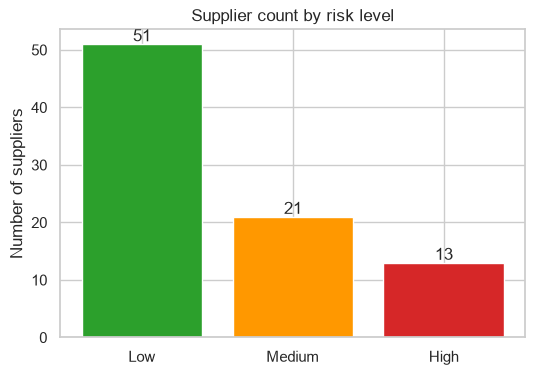

In [6]:
counts = scores_df["risk_level"].value_counts().reindex(RISK_ORDER)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=[RISK_COLORS[level] for level in RISK_ORDER])
ax.set_title("Supplier count by risk level")
ax.set_ylabel("Number of suppliers")
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")
plt.show()

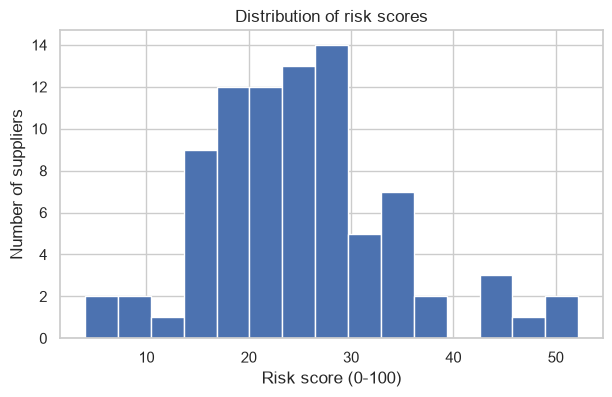

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores_df["risk_score"], bins=15, color="#4c72b0", edgecolor="white")
ax.set_title("Distribution of risk scores")
ax.set_xlabel("Risk score (0-100)")
ax.set_ylabel("Number of suppliers")
plt.show()

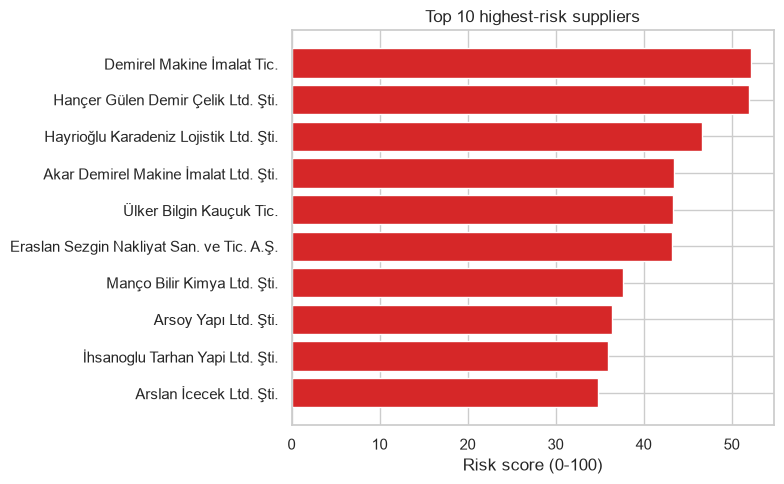

In [8]:
top10 = scores_df.sort_values("risk_score", ascending=False).head(10).iloc[::-1]
colors = [RISK_COLORS[level] for level in top10["risk_level"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10["company_name"], top10["risk_score"], color=colors)
ax.set_title("Top 10 highest-risk suppliers")
ax.set_xlabel("Risk score (0-100)")
plt.tight_layout()
plt.show()

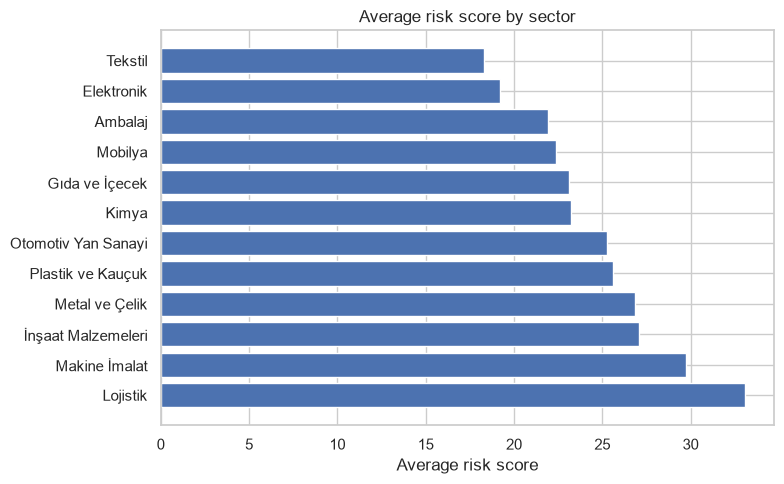

In [9]:
sector_avg = scores_df.groupby("sector")["risk_score"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(sector_avg.index, sector_avg.values, color="#4c72b0")
ax.set_title("Average risk score by sector")
ax.set_xlabel("Average risk score")
plt.tight_layout()
plt.show()

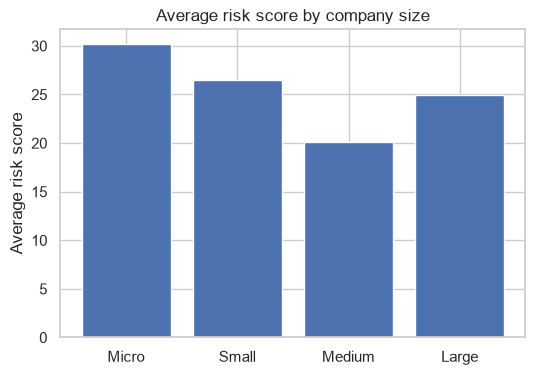

In [10]:
size_order = ["Micro", "Small", "Medium", "Large"]
size_avg = scores_df.groupby("company_size")["risk_score"].mean().reindex(size_order)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(size_avg.index, size_avg.values, color="#4c72b0")
ax.set_title("Average risk score by company size")
ax.set_ylabel("Average risk score")
plt.show()

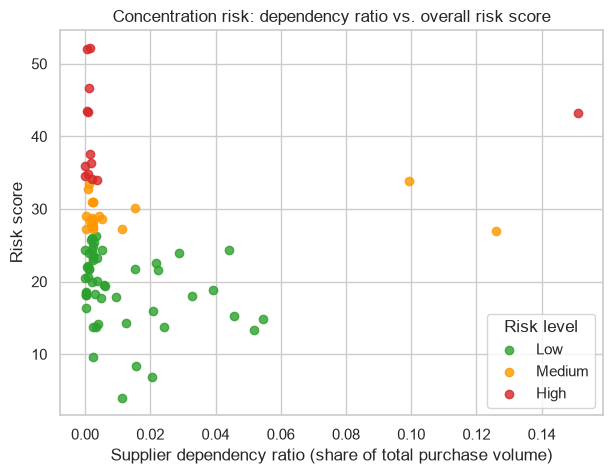

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
for level in RISK_ORDER:
    subset = scores_df[scores_df["risk_level"] == level]
    ax.scatter(subset["supplier_dependency_ratio"], subset["risk_score"],
               color=RISK_COLORS[level], label=level, alpha=0.8)
ax.set_xlabel("Supplier dependency ratio (share of total purchase volume)")
ax.set_ylabel("Risk score")
ax.set_title("Concentration risk: dependency ratio vs. overall risk score")
ax.legend(title="Risk level")
plt.show()

## 5. v2: Financial risk axis, portfolio & sector concentration, due-diligence red flags, and CBAM compliance exposure

Everything in this section is deliberately **not blended** into `risk_score` above — see `compute_financial_risk_score`'s docstring in `src/score_suppliers.py` for why. A supplier can be operationally excellent but financially fragile, or vice versa, and merging both into one number would hide which kind of risk is actually driving a rating. Real commercial platforms (e.g. SAP Ariba) keep financial, compliance, and sustainability risk as separate facets for the same reason.

**`financial_risk_score`** (0-100, higher = riskier) is a second, independent axis built from three financial/solvency signals — overdue debt ratio (30%), debt-to-revenue leverage (30%), and a payment-default-in-last-3-years flag (40%) — conceptually inspired by what a real **Findeks Ticari Risk Raporu** (Turkey's actual commercial credit bureau product) covers. It is *not* a reproduction of KKB's actual proprietary scoring formula, which isn't publicly published.

**Portfolio HHI** (Herfindahl-Hirschman Index) is a real, standard economics concentration metric — the sum of each supplier's squared share of total spend, scaled to the conventional 0-10,000 range, using the same DOJ antitrust-review thresholds (<1,500 low, 1,500-2,500 moderate, >2,500 high concentration).

**Sector-level HHI** applies the same formula *within* each sector rather than across the whole portfolio — closing a limitation the v1 README documented explicitly: a supplier that's 12% of all purchasing can look safe under portfolio-wide HHI, even while being 60%+ of a smaller sector and a real single point of failure there.

**Red flags** (`has_export_documentation`, `requires_full_upfront_payment`, `site_visit_verified`) are qualitative, practitioner-grounded due-diligence signals — not derived from a formula, but from concrete criteria a real Turkish sourcing consultant described using to vet suppliers in practice.

**CBAM compliance exposure** (`cbam_compliance_risk`) is a boolean applicability + gap check, not a score: is this supplier in a CBAM-covered sector (`config/cbam_sectors.yaml` — only `Metal ve Çelik` maps honestly onto this project's sector list), does it export to the EU, and does it lack the emissions-reporting capability CBAM/CSRD actually requires? The EU's Carbon Border Adjustment Mechanism enters its definitive regime in **2026** and names Turkey specifically (alongside China and India) as among the most-exposed countries for steel/aluminum exports — a concrete, dated compliance risk, not a hypothetical one.

Portfolio concentration (HHI): 658 / 10,000 (low concentration)



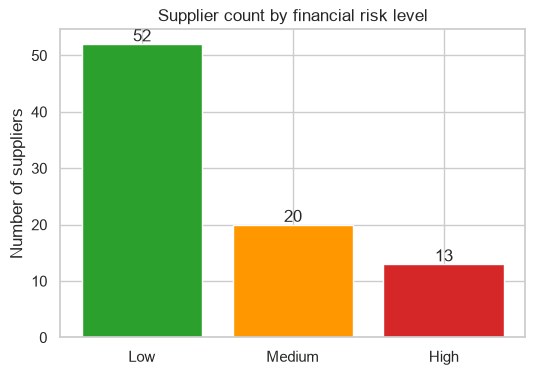

In [12]:
from score_suppliers import compute_portfolio_hhi

portfolio_hhi = compute_portfolio_hhi(scores_df["supplier_dependency_ratio"])
hhi_level = "low" if portfolio_hhi < 1_500 else "moderate" if portfolio_hhi < 2_500 else "high"
print(f"Portfolio concentration (HHI): {portfolio_hhi:.0f} / 10,000 ({hhi_level} concentration)")
print()

fin_counts = scores_df["financial_risk_level"].value_counts().reindex(RISK_ORDER)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(fin_counts.index, fin_counts.values, color=[RISK_COLORS[level] for level in RISK_ORDER])
ax.set_title("Supplier count by financial risk level")
ax.set_ylabel("Number of suppliers")
for i, v in enumerate(fin_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")
plt.show()

,sector,sector_hhi,supplier_count,total_purchase_volume_tl,concentration_level
0,Gıda ve İçecek,6801.632985,7,5.793141e+08,High
1,Plastik ve Kauçuk,6571.905514,4,5.347801e+07,High
2,Elektronik,5123.064416,3,2.543833e+08,High
3,İnşaat Malzemeleri,4957.096366,7,1.790697e+08,High
4,Ambalaj,4429.676780,6,1.550634e+08,High
5,Mobilya,4190.805608,10,3.072711e+08,High
6,Lojistik,3929.409775,6,1.105439e+09,High
7,Kimya,3906.264001,8,4.288836e+08,High
8,Metal ve Çelik,3854.244243,10,1.396746e+08,High
9,Makine İmalat,3790.392068,7,1.317006e+08,High


12 of 12 sectors are highly concentrated (HHI > 2,500) even though the portfolio-wide HHI above is low — confirming why sector-level concentration needs its own check.


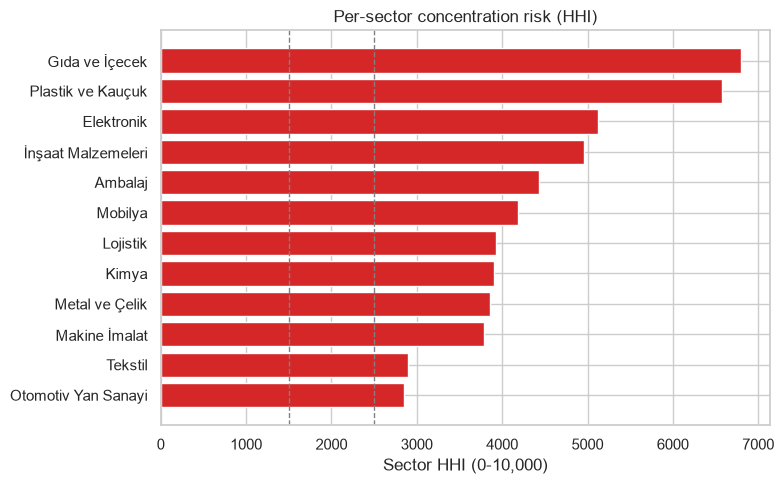

In [13]:
# Per-sector HHI: portfolio-wide HHI alone can hide a sector that's actually
# very concentrated, if that sector is small relative to total spend. This
# directly answers the v1 README's own documented limitation.
from score_suppliers import compute_metrics, compute_sector_hhi

sector_hhi_df = compute_sector_hhi(compute_metrics(clean_df))
display(sector_hhi_df)

high_concentration_sectors = (sector_hhi_df["concentration_level"] == "High").sum()
print(f"{high_concentration_sectors} of {len(sector_hhi_df)} sectors are highly concentrated "
      f"(HHI > 2,500) even though the portfolio-wide HHI above is low — "
      "confirming why sector-level concentration needs its own check.")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d62728" if lvl == "High" else "#ff9800" if lvl == "Moderate" else "#2ca02c"
          for lvl in sector_hhi_df["concentration_level"]]
ax.barh(sector_hhi_df["sector"], sector_hhi_df["sector_hhi"], color=colors)
ax.axvline(1500, color="gray", linestyle="--", linewidth=1)
ax.axvline(2500, color="gray", linestyle="--", linewidth=1)
ax.invert_yaxis()
ax.set_xlabel("Sector HHI (0-10,000)")
ax.set_title("Per-sector concentration risk (HHI)")
plt.tight_layout()
plt.show()

Overlap between top-10 operationally-riskiest and top-10 financially-riskiest suppliers: 3 / 10


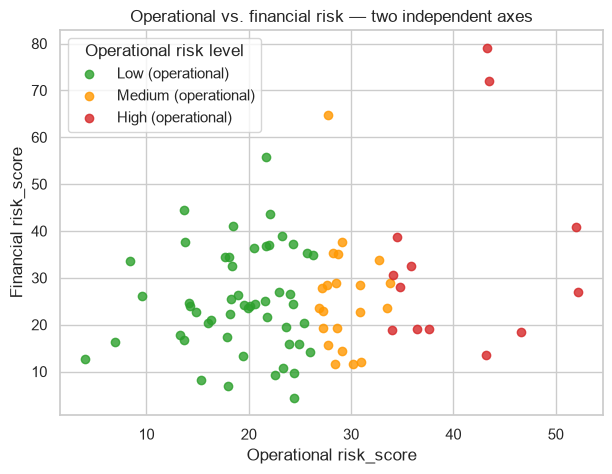

In [14]:
# The whole point of keeping the two axes separate: are they actually telling
# a different story, or is financial_risk_score just a re-scaled copy of risk_score?
top10_operational = set(scores_df.sort_values("risk_score", ascending=False).head(10)["company_name"])
top10_financial = set(scores_df.sort_values("financial_risk_score", ascending=False).head(10)["company_name"])
overlap = top10_operational & top10_financial
print(f"Overlap between top-10 operationally-riskiest and top-10 financially-riskiest suppliers: {len(overlap)} / 10")

fig, ax = plt.subplots(figsize=(7, 5))
for level in RISK_ORDER:
    subset = scores_df[scores_df["risk_level"] == level]
    ax.scatter(subset["risk_score"], subset["financial_risk_score"],
               color=RISK_COLORS[level], label=f"{level} (operational)", alpha=0.8)
ax.set_xlabel("Operational risk_score")
ax.set_ylabel("Financial risk_score")
ax.set_title("Operational vs. financial risk — two independent axes")
ax.legend(title="Operational risk level")
plt.show()

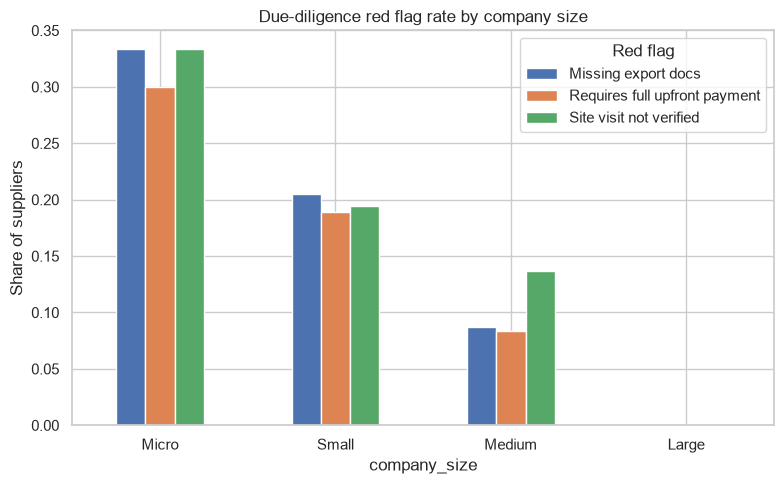

In [15]:
# Red flags live in the cleaned dataset (clean_df), not the scored output —
# they're qualitative due-diligence signals, not inputs to either risk score.
# A handful of rows have a missing (NaN) flag value (simulated messy-export
# data); cast to pandas' nullable boolean dtype so those are skipped by
# .mean() rather than crashing the invert operator.
export_docs = clean_df["has_export_documentation"].astype("boolean")
upfront_payment = clean_df["requires_full_upfront_payment"].astype("boolean")
site_visit = clean_df["site_visit_verified"].astype("boolean")
size_order_4tier = ["Micro", "Small", "Medium", "Large"]

# For "requires_full_upfront_payment", True is the red flag; for the other two, False is.
red_flag_rate = pd.DataFrame({
    "Missing export docs": (~export_docs).groupby(clean_df["company_size"]).mean(),
    "Requires full upfront payment": upfront_payment.groupby(clean_df["company_size"]).mean(),
    "Site visit not verified": (~site_visit).groupby(clean_df["company_size"]).mean(),
}).astype(float).reindex(size_order_4tier)

ax = red_flag_rate.plot(kind="bar", figsize=(8, 5))
ax.set_title("Due-diligence red flag rate by company size")
ax.set_ylabel("Share of suppliers")
ax.legend(title="Red flag")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
from score_suppliers import compute_cbam_compliance_risk, load_cbam_config

cbam_sectors = load_cbam_config("../config/cbam_sectors.yaml")
print(f"CBAM-covered sectors in this project's sector list: {cbam_sectors}")

cbam_flag = compute_cbam_compliance_risk(clean_df, cbam_sectors)
exposed = clean_df.loc[cbam_flag, ["company_name", "sector", "city", "company_size"]]
print(f"\nSuppliers with a CBAM compliance exposure (in-scope sector, exports to EU, "
      f"no emissions-reporting capability): {len(exposed)} of {len(clean_df)}")
exposed

CBAM-covered sectors in this project's sector list: ['Metal ve Çelik']

Suppliers with a CBAM compliance exposure (in-scope sector, exports to EU, no emissions-reporting capability): 1 of 85


,company_name,sector,city,company_size
65,Yorulmaz Çelik San. ve Tic. A.Ş.,Metal ve Çelik,Denizli,Medium


## 6. Weight sensitivity (bonus)

The scoring weights are a business decision, not a fixed fact — so it's worth checking how much the ranking actually changes if priorities shift. Below, the same cleaned data is re-scored under three weight profiles using the exact same `compute_metrics` / `compute_risk_score` functions from `src/score_suppliers.py` (proving the pipeline is genuinely reusable, not just a one-off script).

In [17]:
from score_suppliers import compute_metrics, compute_risk_score

metrics_df = compute_metrics(clean_df)

scenarios = {
    "Default (delivery-focused)": {
        "delivery_delay_rate": 0.35, "price_volatility": 0.25,
        "supplier_dependency_ratio": 0.25, "quality_return_rate": 0.15,
    },
    "Cost-focused": {
        "delivery_delay_rate": 0.15, "price_volatility": 0.45,
        "supplier_dependency_ratio": 0.25, "quality_return_rate": 0.15,
    },
    "Quality-focused": {
        "delivery_delay_rate": 0.20, "price_volatility": 0.15,
        "supplier_dependency_ratio": 0.15, "quality_return_rate": 0.50,
    },
}

comparison = pd.DataFrame({"company_name": metrics_df["company_name"]})
for name, weights in scenarios.items():
    config = {"weights": weights, "risk_level_thresholds": {"low_percentile": 0.60, "high_percentile": 0.85}}
    scored = compute_risk_score(metrics_df, config)
    comparison[name] = scored["risk_score"]

comparison.sort_values("Default (delivery-focused)", ascending=False).head(8)

,company_name,Default (delivery-focused),Cost-focused,Quality-focused
38,Demirel Makine İmalat Tic.,52.2,55.8,36.5
33,Hançer Gülen Demir Çelik Ltd. Şti.,52.0,50.0,71.6
72,Hayrioğlu Karadeniz Lojistik Ltd. Şti.,46.6,54.5,28.4
48,Akar Demirel Makine İmalat Ltd. Şti.,43.5,29.4,27.8
37,Ülker Bilgin Kauçuk Tic.,43.3,42.6,29.6
83,Eraslan Sezgin Nakliyat San. ve Tic. A.Ş.,43.2,34.7,27.0
20,Manço Bilir Kimya Ltd. Şti.,37.6,27.5,31.1
77,Arsoy Yapı Ltd. Şti.,36.4,31.8,28.1


## 7. AHP-derived weights — checking the asserted weights rigorously

The default weights above (35/25/25/15) are a defensible but **asserted** rationale — someone reasoned about it and picked numbers. The Analytic Hierarchy Process (AHP) is the academically standard alternative: state pairwise judgments ("how much more important is delivery than price?") on Saaty's 1-9 scale, then derive weights mathematically from those judgments via the principal eigenvector method — with a built-in **Consistency Ratio (CR)** that catches self-contradictory judgments (e.g. A > B, B > C, but C > A) rather than trusting they're coherent by inspection.

The pairwise judgments themselves live in `config/ahp_pairwise_comparisons.yaml`, each with its own documented rationale; `src/ahp.py` derives the weights and CR from them.

Consistency Ratio: 0.0038 (consistent, threshold 0.10)



,AHP-derived,Asserted (default),Difference
delivery_delay_rate,0.424,0.35,0.074
price_volatility,0.227,0.25,-0.023
supplier_dependency_ratio,0.227,0.25,-0.023
quality_return_rate,0.122,0.15,-0.028


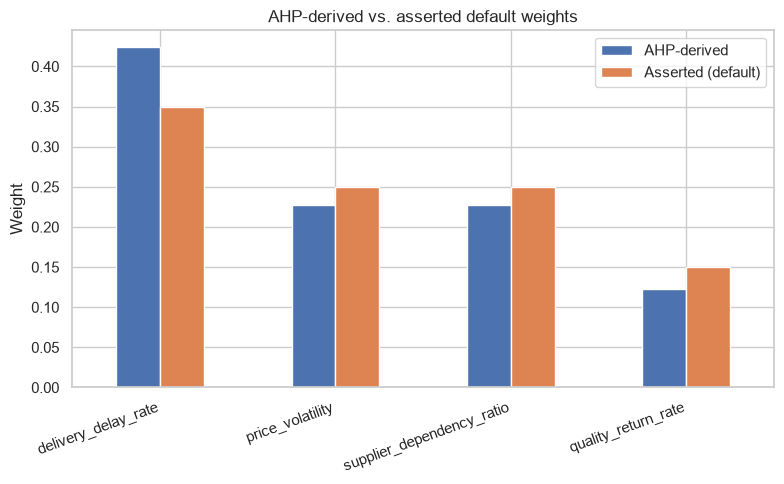

In [18]:
from ahp import derive_weights_from_config

ahp_result = derive_weights_from_config("../config/ahp_pairwise_comparisons.yaml")

print(f"Consistency Ratio: {ahp_result['consistency_ratio']:.4f} "
      f"({'consistent' if ahp_result['is_consistent'] else 'INCONSISTENT'}, threshold 0.10)")
print()

asserted_weights = scenarios["Default (delivery-focused)"]
weight_comparison = pd.DataFrame({
    "AHP-derived": ahp_result["weights"],
    "Asserted (default)": asserted_weights,
})
weight_comparison["Difference"] = weight_comparison["AHP-derived"] - weight_comparison["Asserted (default)"]
display(weight_comparison.round(3))

ax = weight_comparison[["AHP-derived", "Asserted (default)"]].plot(kind="bar", figsize=(8, 5), color=["#4c72b0", "#dd8452"])
ax.set_title("AHP-derived vs. asserted default weights")
ax.set_ylabel("Weight")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [19]:
# Does re-scoring with the AHP-derived weights actually change who's flagged as riskiest?
ahp_config = {"weights": ahp_result["weights"], "risk_level_thresholds": {"low_percentile": 0.60, "high_percentile": 0.85}}
ahp_scored = compute_risk_score(metrics_df, ahp_config)
comparison["AHP-derived"] = ahp_scored["risk_score"]

# Spearman rank correlation, computed without scipy: Pearson correlation of
# the ranks is mathematically identical to Spearman's rho.
rank_correlation = comparison["Default (delivery-focused)"].rank().corr(comparison["AHP-derived"].rank())
print(f"Rank correlation (Spearman) between asserted-weight and AHP-weight rankings: {rank_correlation:.3f}")
print("(1.0 would mean an identical ranking; AHP is a cross-check, not expected to match exactly.)")
print()
comparison.sort_values("Default (delivery-focused)", ascending=False).head(8)[["company_name", "Default (delivery-focused)", "AHP-derived"]]

Rank correlation (Spearman) between asserted-weight and AHP-weight rankings: 0.985
(1.0 would mean an identical ranking; AHP is a cross-check, not expected to match exactly.)



,company_name,Default (delivery-focused),AHP-derived
38,Demirel Makine İmalat Tic.,52.2,55.3
33,Hançer Gülen Demir Çelik Ltd. Şti.,52.0,52.9
72,Hayrioğlu Karadeniz Lojistik Ltd. Şti.,46.6,48.7
48,Akar Demirel Makine İmalat Ltd. Şti.,43.5,49.9
37,Ülker Bilgin Kauçuk Tic.,43.3,46.7
83,Eraslan Sezgin Nakliyat San. ve Tic. A.Ş.,43.2,44.1
20,Manço Bilir Kimya Ltd. Şti.,37.6,42.1
77,Arsoy Yapı Ltd. Şti.,36.4,39.7


## 8. Risk trend over time — closing the point-in-time gap

Everything above scores a **single snapshot**. That's a real, documented limitation of how supplier risk is actually managed in practice: `docs/research_v2.md` section 2.2 cites that supplier risk tiers "rarely get revisited after onboarding" — a supplier can move from low to high risk within weeks (a leadership change, a new default, a lost certification) and nothing catches it if the score is only ever computed once.

`src/generate_supplier_history.py` generates the same 85 suppliers re-assessed across four quarters, with performance/financial metrics drifting period to period via a bounded random walk (not independently re-randomized — supplier identity fields like name, sector, and VKN stay fixed). `src/risk_trend.py` then scores every period independently using the **exact same** `compute_metrics` / `compute_risk_score` / `compute_financial_risk_score` functions used above (not a parallel reimplementation), and flags every period-to-period **risk migration** — a transition into a strictly worse risk category.

In [20]:
from risk_trend import detect_risk_migrations

trend_df = pd.read_csv("../reports/supplier_risk_trend.csv", encoding="utf-8-sig")
periods = sorted(trend_df["period"].unique())
print(f"{trend_df['supplier_id'].nunique()} suppliers scored across {len(periods)} periods: {periods}")
print()

operational_migrations = detect_risk_migrations(trend_df, "risk_level")
financial_migrations = detect_risk_migrations(trend_df, "financial_risk_level")
print(f"Operational risk migrations (moved to a worse category): {len(operational_migrations)} "
      f"across {operational_migrations['supplier_id'].nunique()} suppliers")
print(f"Financial risk migrations (moved to a worse category):   {len(financial_migrations)} "
      f"across {financial_migrations['supplier_id'].nunique()} suppliers")
print()
print("Sample of flagged operational migrations:")
operational_migrations[["company_name", "period_from", "period_to", "level_from", "level_to"]].head(8)

85 suppliers scored across 4 periods: ['2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']



Operational risk migrations (moved to a worse category): 37 across 35 suppliers


Financial risk migrations (moved to a worse category):   29 across 26 suppliers

Sample of flagged operational migrations:


,company_name,period_from,period_to,level_from,level_to
0,Korutürk Aslan İplik San. Tic. Ltd. Şti.,2025-Q3,2025-Q4,Low,Medium
1,Yaman Korutürk Oto Yedek Parça San. Tic. Ltd. ...,2025-Q1,2025-Q2,Low,Medium
2,Yaman Korutürk Oto Yedek Parça San. Tic. Ltd. ...,2025-Q3,2025-Q4,Low,High
3,Korutürk Makine İmalat San. Tic. Ltd. Şti.,2025-Q2,2025-Q3,Low,Medium
4,Bilir Kimya Ltd. Şti.,2025-Q2,2025-Q3,Low,Medium
5,Tevetoğlu Otomotiv Tic.,2025-Q2,2025-Q3,Medium,High
6,Akar Demirel Makine İmalat Ltd. Şti.,2025-Q2,2025-Q3,Medium,High
7,Dumanli Zengin Otomotiv Ltd. Şti.,2025-Q3,2025-Q4,Low,Medium


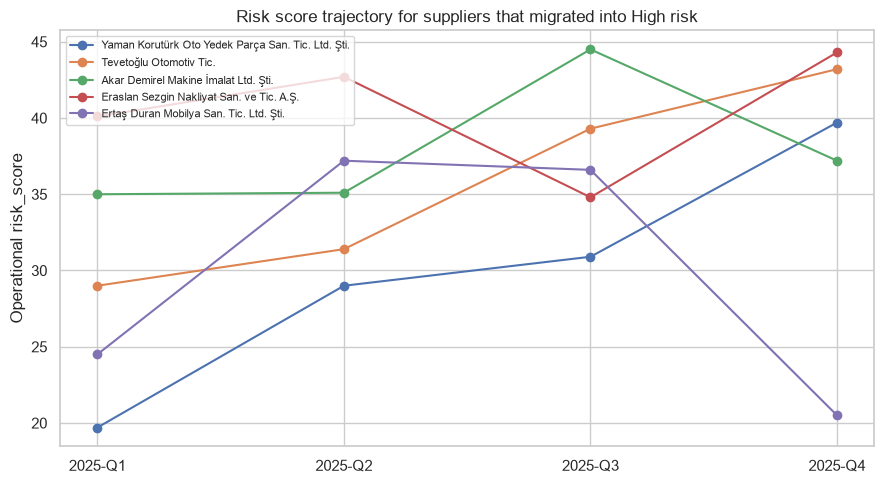

In [21]:
# Plot the risk_score trajectory for a handful of suppliers that migrated
# into High risk at some point -- the concrete "would have been missed by a
# single snapshot" case.
migrated_to_high_ids = operational_migrations.loc[
    operational_migrations["level_to"] == "High", "supplier_id"
].unique()[:5]

fig, ax = plt.subplots(figsize=(9, 5))
for supplier_id in migrated_to_high_ids:
    supplier_trend = trend_df[trend_df["supplier_id"] == supplier_id].sort_values("period")
    label = supplier_trend["company_name"].iloc[-1]
    ax.plot(supplier_trend["period"], supplier_trend["risk_score"], marker="o", label=label)

ax.set_ylabel("Operational risk_score")
ax.set_title("Risk score trajectory for suppliers that migrated into High risk")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## Key takeaways

- Of 85 synthetic suppliers, the operational-risk pipeline flags roughly the riskiest ~15% as **High** and the safest ~60% as **Low**, using percentile-based cutoffs so the labels stay meaningful regardless of how the underlying scores are distributed.
- The single highest-risk supplier is high-risk mainly because of **concentration risk**: its `supplier_dependency_ratio_score` is close to 100/100 under the HHI-inspired squared-share normalization — a concrete, explainable driver, not a black box.
- **Operational and financial risk are genuinely different dimensions**, not two views of the same thing: the top-10 operationally-riskiest and top-10 financially-riskiest suppliers overlap only partially, confirming that blending them into one score would have hidden which kind of risk actually applies to a given supplier.
- **Portfolio-wide HHI can hide real concentration risk that sector-level HHI catches**: the portfolio HHI here is low (658/10,000), but every one of the 12 sectors is individually highly concentrated (HHI > 2,500) — exactly the gap the v1 README documented as a known limitation, now closed with a per-sector breakdown (`compute_sector_hhi`).
- **Due-diligence red flags** (missing export documentation, demanding full upfront payment, no verified site visit) are markedly more common among Micro suppliers than Large ones — consistent with the size-tiered generation logic, and a concrete example of a qualitative signal that a purely numeric scorecard would miss.
- **CBAM compliance exposure is a real, dated, and — on this dataset — rare risk**: only 1 of 85 suppliers hits all three conditions (a CBAM-covered sector, exports to the EU, no emissions-reporting capability). That's the point of a boolean applicability check rather than a broad estimate — it names a specific supplier a real buyer could act on immediately, instead of a vague "some suppliers might be affected."
- Scoring weights are configurable (`config/scoring_weights.yaml`), and re-running the same scoring functions under different weight profiles shows the ranking is genuinely sensitive to business priorities — e.g. a cost-focused company would flag a different top-risk supplier than a delivery-focused one.
- **AHP provided a mathematical consistency check on the asserted defaults**, not a fully independent second opinion — the pairwise judgments in `config/ahp_pairwise_comparisons.yaml` were informed by the same underlying reasoning as the original weights, honestly documented as such in that file's own comments. What AHP adds isn't a different opinion, it's *proof the opinion is logically coherent*: the Consistency Ratio (0.004, well under Saaty's 0.10 threshold) confirms the six pairwise judgments don't contradict each other (e.g. no case of "A > B, B > C, but C > A"), and decomposing one global weighting decision into six simpler binary judgments is easier to sanity-check individually than eyeballing four percentages at once. The derived weights (within a few points of 35/25/25/15) and nearly identical resulting ranking (Spearman rank correlation ≈0.99) are the expected result of that consistency, not a coincidence.
- **A single snapshot would have missed a lot**: re-scoring the same 85 suppliers across four synthetic quarters surfaced 37 operational and 29 financial risk migrations (a supplier moving into a strictly worse risk category) across 35 and 26 suppliers respectively — real risk drift that a one-time assessment, run once at onboarding and never revisited, would never catch. This is exactly the documented industry gap `docs/research_v2.md` section 2.2 describes, closed here with `src/generate_supplier_history.py` and `src/risk_trend.py` reusing the same scoring functions as the point-in-time pipeline, not a parallel implementation.
- Cleaning decisions were made explicitly and conservatively, via a profile-driven engine that has zero knowledge of *this specific* dataset: structured fields (sector, city, category labels, VKN tax IDs) were fully recovered/validated via canonical matching and a real checksum algorithm, while free-text fields with already-lost information (company name diacritics) were left as-is rather than guessed — an intentional, documented data-quality boundary.